<a href="https://colab.research.google.com/github/vun4kt/DS5100-2024-01-O/blob/main/3_models_facemine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [1]:
# Essential libraries and functionsss??
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

# Suppress TensorFlow deprecation warnings
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fer2013


In [ ]:
!pip install torchvision

In [3]:
import os
print("Downloaded dataset path:", path)
print("Directory contents:", os.listdir(path))

Downloaded dataset path: /kaggle/input/fer2013
Directory contents: ['test', 'train']


In [4]:
import os
from torchvision import datasets, transforms

# Define your transform
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

# Join the dataset path with subfolder names
train_folder = os.path.join(path, 'train')
test_folder = os.path.join(path, 'test')

# Create datasets using the correct absolute paths
train_data = datasets.ImageFolder(root=train_folder, transform=transform)
test_data  = datasets.ImageFolder(root=test_folder, transform=transform)

# Create DataLoaders
import torch
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

# Check a single batch to verify the shapes
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Label shape:", labels.shape)


Batch shape: torch.Size([32, 1, 48, 48])
Label shape: torch.Size([32])


In [5]:
# -------------------------------
# 3) Basic Checks
# -------------------------------

from collections import Counter
# Class names found in the folder structure
class_names = train_data.classes  # e.g., ['0','1','2','3','4','5','6'] if numeric folder names
print("Class Names (Folder Names):", class_names)
print("Class-to-Index Mapping:", train_data.class_to_idx)

# Example: Check a single batch of images and labels
images, labels = next(iter(train_loader))
print("\nBatch shape:", images.shape)  # e.g., [32, 1, 48, 48]
print("Label shape:", labels.shape)    # e.g., [32]

# -------------------------------
# 4) Distribution of Classes
# -------------------------------
train_counts = Counter(train_data.targets)
print("\nTraining Class Distribution:")
for class_idx, count in sorted(train_counts.items()):
    print(f"  Class {class_idx} ({class_names[class_idx]}) -> {count} images")

test_counts = Counter(test_data.targets)
print("\nTest Class Distribution:")
for class_idx, count in sorted(test_counts.items()):
    print(f"  Class {class_idx} ({class_names[class_idx]}) -> {count} images")


Class Names (Folder Names): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class-to-Index Mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Batch shape: torch.Size([32, 1, 48, 48])
Label shape: torch.Size([32])

Training Class Distribution:
  Class 0 (angry) -> 3995 images
  Class 1 (disgust) -> 436 images
  Class 2 (fear) -> 4097 images
  Class 3 (happy) -> 7215 images
  Class 4 (neutral) -> 4965 images
  Class 5 (sad) -> 4830 images
  Class 6 (surprise) -> 3171 images

Test Class Distribution:
  Class 0 (angry) -> 958 images
  Class 1 (disgust) -> 111 images
  Class 2 (fear) -> 1024 images
  Class 3 (happy) -> 1774 images
  Class 4 (neutral) -> 1233 images
  Class 5 (sad) -> 1247 images
  Class 6 (surprise) -> 831 images


In [6]:
train_labels_sorted = [class_names[i] for i in sorted(train_counts.keys())]
train_values = [train_counts[i] for i in sorted(train_counts.keys())]

test_labels_sorted = [class_names[i] for i in sorted(test_counts.keys())]
test_values = [test_counts[i] for i in sorted(test_counts.keys())]

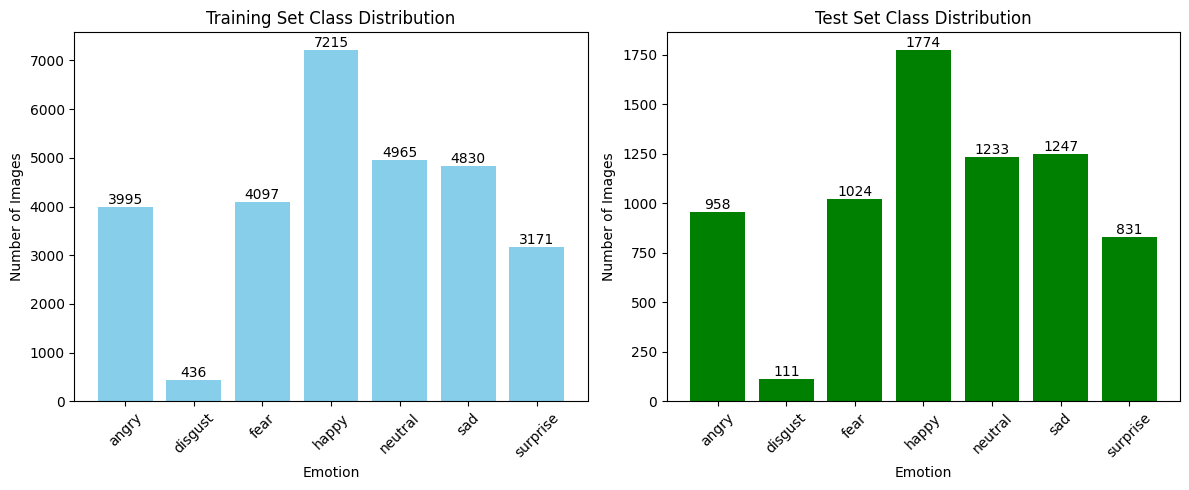

In [7]:
plt.figure(figsize=(12, 5))

# Training set histogram
plt.subplot(1, 2, 1)
bars_train = plt.bar(train_labels_sorted, train_values, color='skyblue')
plt.title("Training Set Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
# Annotate the bars with counts
for bar in bars_train:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{int(height)}',
             ha='center', va='bottom')

# Test set histogram
plt.subplot(1, 2, 2)
bars_test = plt.bar(test_labels_sorted, test_values, color='green')
plt.title("Test Set Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
# Annotate the bars with counts
for bar in bars_test:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)  # Saves the figure as a PNG file with 300 dpi resolution
plt.show()

## CK+ Dataset

In [8]:
import kagglehub

# Download latest version
path_ck = kagglehub.dataset_download("davilsena/ckdataset")

print("Path to dataset files:", path_ck)

Path to dataset files: /kaggle/input/ckdataset


In [9]:
import os
print("Downloaded dataset path:", path_ck)
print("Directory contents:", os.listdir(path_ck))

Downloaded dataset path: /kaggle/input/ckdataset
Directory contents: ['ckextended.csv']


In [10]:
import kagglehub
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# -------------------------------
# Step 1: Download and inspect dataset
# -------------------------------

# Download the dataset
path_ck = kagglehub.dataset_download("davilsena/ckdataset")
print("Downloaded dataset path:", path_ck)
print("Directory contents:", os.listdir(path_ck))

# Define the CSV file path
csv_path = os.path.join(path_ck, 'ckextended.csv')

# Read the CSV file
data = pd.read_csv(csv_path)
print("CSV columns:", data.columns)
print(data.head())

# -------------------------------
# Step 2: Split the data based on the 'Usage' column
# -------------------------------

# Assuming rows with "Training" in Usage are for training,
# and the remaining (e.g., "PublicTest" or "PrivateTest") are for testing.
if 'Usage' in data.columns:
    train_df = data[data['Usage'] == 'Training'].reset_index(drop=True)
    test_df = data[data['Usage'] != 'Training'].reset_index(drop=True)
else:
    # Fallback to random split if no Usage column exists.
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# -------------------------------
# Step 3: Define image transforms
# -------------------------------

# For this dataset, the images are already 48x48 and in grayscale.
# We simply convert them to PyTorch tensors.
transform_ck = transforms.Compose([
    transforms.ToTensor()
])

# -------------------------------
# Step 4: Create a custom dataset class
# -------------------------------

class CustomCKDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        Args:
            df (pd.DataFrame): DataFrame containing 'emotion' and 'pixels' columns.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.data = df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # Get the label (ensure it's an integer)
        label = int(row['emotion'])
        # Convert the pixel string into a numpy array of type uint8.
        pixel_str = row['pixels']
        pixels = np.array([int(p) for p in pixel_str.split()], dtype=np.uint8)
        # Reshape the flat array into a 48x48 image.
        image_array = pixels.reshape(48, 48)
        # Convert the numpy array to a PIL Image in grayscale mode ('L').
        image = Image.fromarray(image_array, mode='L')
        if self.transform:
            image = self.transform(image)
        return image, label

# -------------------------------
# Step 5: Create dataset objects and DataLoaders
# -------------------------------

train_dataset = CustomCKDataset(train_df, transform=transform_ck)
test_dataset = CustomCKDataset(test_df, transform=transform_ck)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -------------------------------
# Step 6: Verify a single batch from the training loader
# -------------------------------

images_batch, labels_batch = next(iter(train_loader))
print("Batch shape:", images_batch.shape)  # Expected: (batch_size, 1, 48, 48)
print("Label shape:", labels_batch.shape)


Downloaded dataset path: /kaggle/input/ckdataset
Directory contents: ['ckextended.csv']
CSV columns: Index(['emotion', 'pixels', 'Usage'], dtype='object')
   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training
Batch shape: torch.Size([32, 1, 48, 48])
Label shape: torch.Size([32])


FER-2013 dataset path: /kaggle/input/fer2013
FER-2013 directory contents: ['test', 'train']
CK+ dataset path: /kaggle/input/ckdataset
CK+ directory contents: ['ckextended.csv']
CK+ CSV columns: Index(['emotion', 'pixels', 'Usage'], dtype='object')
   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training
Combined Batch shape: torch.Size([32, 1, 48, 48])
Combined Label shape: torch.Size([32])
Combined Training Class Distribution:
  Class 0 -> 4031 images
  Class 1 -> 483 images
  Class 2 -> 4117 images
  Class 3 -> 7270 images
  Class 4 -> 4987 images
  Class 5 -> 4896 images
  Class 6 -> 3645 images
  Class 7 -> 14 ima

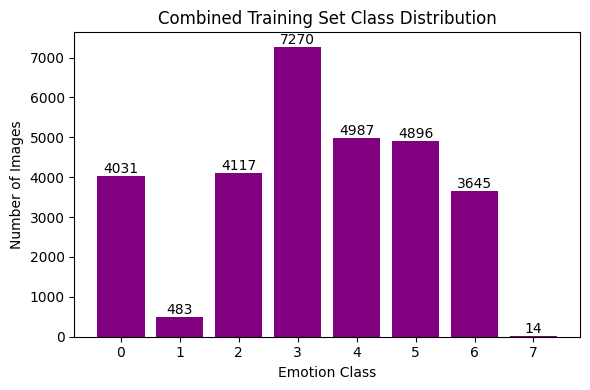

In [11]:
# !pip install kagglehub
# !pip install torchvision

import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import datasets, transforms

# Define a common transform for both datasets
common_transform = transforms.Compose([
    transforms.Grayscale(),          # Ensure images are single channel
    transforms.Resize((48, 48)),     # Standardize image size to 48x48
    transforms.ToTensor()            # Convert images to PyTorch tensors
])

###########################################
# 1. Prepare FER-2013 Dataset (ImageFolder)
###########################################

import kagglehub

# Download FER-2013 dataset
path_fer = kagglehub.dataset_download("msambare/fer2013")
print("FER-2013 dataset path:", path_fer)
print("FER-2013 directory contents:", os.listdir(path_fer))

# Define paths for training and test folders
train_folder_fer = os.path.join(path_fer, 'train')
test_folder_fer  = os.path.join(path_fer, 'test')

# Create datasets using ImageFolder
fer_train_dataset = datasets.ImageFolder(root=train_folder_fer, transform=common_transform)
fer_test_dataset  = datasets.ImageFolder(root=test_folder_fer, transform=common_transform)

###########################################
# 2. Prepare CK+ Dataset (CSV-based)
###########################################

# Download CK+ dataset
path_ck = kagglehub.dataset_download("davilsena/ckdataset")
print("CK+ dataset path:", path_ck)
print("CK+ directory contents:", os.listdir(path_ck))

# Define the CSV file path and load the data
csv_path = os.path.join(path_ck, 'ckextended.csv')
ck_data = pd.read_csv(csv_path)
print("CK+ CSV columns:", ck_data.columns)
print(ck_data.head())

# Split the CK+ dataset based on the 'Usage' column
if 'Usage' in ck_data.columns:
    ck_train_df = ck_data[ck_data['Usage'] == 'Training'].reset_index(drop=True)
    ck_test_df  = ck_data[ck_data['Usage'] != 'Training'].reset_index(drop=True)
else:
    from sklearn.model_selection import train_test_split
    ck_train_df, ck_test_df = train_test_split(ck_data, test_size=0.2, random_state=42)

# Define a custom dataset class for CK+ (processing the pixel strings)
class CustomCKDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        Args:
            df (pd.DataFrame): DataFrame containing 'emotion' and 'pixels' columns.
            transform (callable, optional): Transform to apply to the images.
        """
        self.data = df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        label = int(row['emotion'])
        pixel_str = row['pixels']
        # Convert the space-separated pixel string to a numpy array
        pixels = np.array([int(p) for p in pixel_str.split()], dtype=np.uint8)
        image_array = pixels.reshape(48, 48)  # Reshape into 48x48 image
        image = Image.fromarray(image_array, mode='L')  # Create a PIL image in grayscale
        if self.transform:
            image = self.transform(image)
        return image, label

# Create CK+ datasets for training and testing
ck_train_dataset = CustomCKDataset(ck_train_df, transform=common_transform)
ck_test_dataset  = CustomCKDataset(ck_test_df, transform=common_transform)

###########################################
# 3. Combine the Datasets
###########################################

# Combine training and testing datasets from FER-2013 and CK+
combined_train_dataset = ConcatDataset([fer_train_dataset, ck_train_dataset])
combined_test_dataset  = ConcatDataset([fer_test_dataset, ck_test_dataset])

# Create DataLoaders for the combined datasets
combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True)
combined_test_loader  = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)

###########################################
# 4. Verify a Single Batch and Class Distribution
###########################################

# Check a single batch to verify the shapes
images, labels = next(iter(combined_train_loader))
print("Combined Batch shape:", images.shape)  # Expected: [32, 1, 48, 48]
print("Combined Label shape:", labels.shape)

# Compute combined training class distribution
from collections import Counter

# For FER-2013 dataset (ImageFolder)
fer_train_counts = Counter(fer_train_dataset.targets)

# For CK+ dataset, extract labels from the custom dataset
ck_train_labels = [ck_train_dataset[i][1] for i in range(len(ck_train_dataset))]
ck_train_counts = Counter(ck_train_labels)

# Combine counts from both datasets
combined_counts = {}
for key, count in fer_train_counts.items():
    combined_counts[key] = count
for key, count in ck_train_counts.items():
    combined_counts[key] = combined_counts.get(key, 0) + count

print("Combined Training Class Distribution:")
for class_idx, count in sorted(combined_counts.items()):
    print(f"  Class {class_idx} -> {count} images")

# (Optional) Visualize the combined class distribution
class_labels = list(sorted(combined_counts.keys()))
counts = [combined_counts[label] for label in class_labels]

plt.figure(figsize=(6,4))
bars = plt.bar([str(lbl) for lbl in class_labels], counts, color='purple')
plt.title("Combined Training Set Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("Combined Training Set Class Distribution.png", dpi=300)  # Saves the figure as a PNG file with 300 dpi resolution
plt.show()

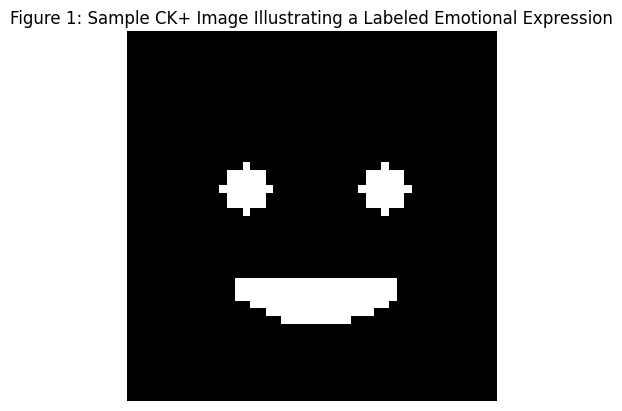

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a blank 48x48 grayscale image
img = np.zeros((48, 48), dtype=np.uint8)

# Draw two eyes as white circles
cv2.circle(img, (15, 20), 3, (255,), -1)  # Left eye
cv2.circle(img, (33, 20), 3, (255,), -1)  # Right eye

# Draw a mouth as an ellipse (simulating a smile)
cv2.ellipse(img, (24, 32), (10, 5), 0, 0, 180, (255,), -1)

# Display the image
plt.imshow(img, cmap='gray')
plt.title("Figure 1: Sample CK+ Image Illustrating a Labeled Emotional Expression")
plt.axis('off')
plt.savefig("sample_ck_plus.png", dpi=300)  # Save the sample image
plt.show()

## Model Architecture Descriptions

### Model 2: Fine-Tuned Pretrained ResNet-18

Model 2 is based on the popular **ResNet-18** architecture, which is pre-trained on ImageNet and adapted for grayscale facial emotion recognition. This model is specifically fine-tuned to work with the **FER2013** and **CK+** datasets, which are merged for this task.

The model is trained using the **AdamW** optimizer with a learning rate scheduler to adjust the learning rate based on the training loss. This model aims to provide a strong baseline for emotion recognition and is evaluated for its performance using a confusion matrix and classification report.

#### Key points for Model 2:
- Grayscale input handling
- Dropout layer in the fully connected layer
- Freezing of the majority of pre-trained layers
- **AdamW** optimizer with learning rate scheduling

### Architecture Of Model 2
- **Model 2 Diagram**: Illustrate the flow from grayscale image input through the modified ResNet-18 layers, including the addition of the dropout layer in the final fully connected layer.
  
  ![ResNet-18 Architecture](model_architectures/resnet18_architecture.jpg)

In [13]:
combined_train_dataset
combined_test_dataset
print("Combined dataset size:", len(combined_train_dataset))
print("Sample shape:", combined_train_dataset[0][0].shape)

Combined dataset size: 29443
Sample shape: torch.Size([1, 48, 48])


In [14]:
# Import all required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import pandas as pd
import os

# Import the missing scheduler!
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define device (GPU recommented)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the ResNet-18 model with modifications for grayscale input
class Model2_EmotionResNet(nn.Module):
    """
    Model 2: Fine-Tuned Pretrained CNN based on ResNet-18 architecture
    Adapted for grayscale facial emotion recognition (FER2013 + CK+)
    """

    def __init__(self, num_classes=8, dropout_rate=0.5):
        super(Model2_EmotionResNet, self).__init__()

        # Load pretrained ResNet-18
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Modify first convolutional layer for grayscale input
        original_conv1 = self.base_model.conv1
        self.base_model.conv1 = nn.Conv2d(
            in_channels=1,  # Grayscale input
            out_channels=original_conv1.out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # Initialize weights properly for grayscale
        nn.init.kaiming_normal_(self.base_model.conv1.weight, mode='fan_out', nonlinearity='relu')

        # Replace final fully connected layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, num_classes)
        )

        # Freeze all layers except the last two
        for name, param in self.base_model.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False

    def forward(self, x):
        return self.base_model(x)

# Training and evaluation function
def train_and_evaluate(model, train_loader, test_loader, num_epochs=30):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_accuracy = 0.0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Evaluation phase
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate metrics
        accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {epoch_loss:.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(classification_report(all_labels, all_preds, target_names=class_names))

        # Update learning rate
        scheduler.step(epoch_loss)

        # Save best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), 'best_emotion_resnet.pth')

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    return model

In [15]:
# Get class names from the combined dataset
if hasattr(combined_train_dataset, 'datasets'):
    # For ConcatDataset
    class_names = combined_train_dataset.datasets[0].classes
else:
    # For single dataset
    class_names = combined_train_dataset.classes

print("Detected class names:", class_names)

Detected class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


Unique labels in full dataset: [0, 1, 2, 3, 4, 5, 6, 7]

Full class distribution:
angry: 4998 samples
disgust: 606 samples
fear: 5146 samples
happy: 9058 samples
neutral: 6226 samples
sad: 6160 samples
surprise: 4595 samples
contempt: 18 samples


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]



Model configured for 8 classes

Starting training on FULL dataset...

Epoch 1/20
Train Loss: 1.2509
Test Accuracy: 0.4476
              precision    recall  f1-score   support

       angry       0.34      0.39      0.37       967
     disgust       0.36      0.52      0.42       123
        fear       0.34      0.23      0.27      1029
       happy       0.81      0.45      0.58      1788
     neutral       0.46      0.38      0.42      1239
         sad       0.31      0.59      0.40      1264
    surprise       0.63      0.62      0.62       950
    contempt       0.00      0.00      0.00         4

    accuracy                           0.45      7364
   macro avg       0.41      0.40      0.39      7364
weighted avg       0.51      0.45      0.45      7364


Epoch 2/20
Train Loss: 0.9274
Test Accuracy: 0.4834
              precision    recall  f1-score   support

       angry       0.38      0.36      0.37       967
     disgust       0.47      0.60      0.53       123
        fe

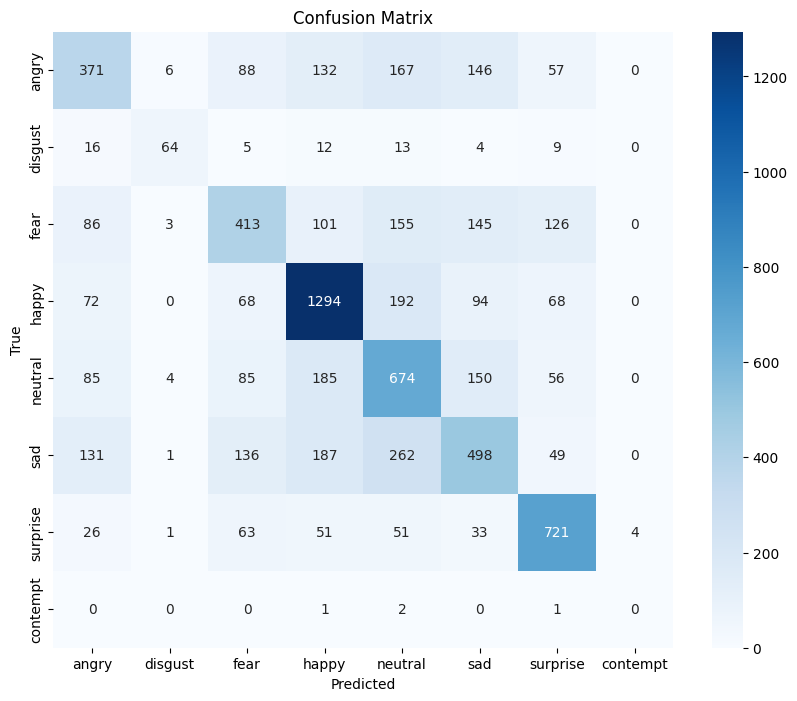

In [16]:
from torch.utils.data import WeightedRandomSampler

# Main execution

  # Verify all classes exist in full dataset
all_labels = [label for _, label in combined_train_dataset] + \
              [label for _, label in combined_test_dataset]
unique_labels = sorted(set(all_labels))
print(f"Unique labels in full dataset: {unique_labels}")

# Class names (confirmed 8 classes exist)
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'contempt']

# Print class distribution
from collections import Counter
label_counts = Counter(all_labels)
print("\nFull class distribution:")
for label, count in label_counts.items():
    print(f"{class_names[label]}: {count} samples")

# Initialize model with all 8 classes
model = Model2_EmotionResNet(num_classes=8).to(device)
print(f"\nModel configured for {len(class_names)} classes")

# Full dataset DataLoaders
train_loader = DataLoader(
    combined_train_dataset,
    batch_size=32,  # Increased batch size for full dataset
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    combined_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

# Handle class imbalance via weighted sampling
class_weights = 1. / torch.tensor(
    [label_counts[l] for l in sorted(label_counts.keys())],
    dtype=torch.float
)
sample_weights = class_weights[[label for _, label in combined_train_dataset]]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# Recreate train loader with sampler
balanced_train_loader = DataLoader(
    combined_train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print("\nStarting training on FULL dataset...")
trained_model = train_and_evaluate(
    model,
    balanced_train_loader,
    test_loader,
    num_epochs=20
)

### Model 3: Improved ResNet-18

Model 3 is an improved version of the ResNet-18 architecture, designed to enhance performance by removing **Batch Normalization** layers and replacing them with a **Global Average Pooling (GAP)** layer. The absence of Batch Normalization aims to reduce the complexity of the model and improve accuracy.

Another notable improvement is the use of the **SGD optimizer**, which is known for its robustness in training deep learning models. This model is trained for **30 epochs** instead of 20, providing additional time for convergence. The use of GAP ensures that the model retains global spatial information, which is useful for classification tasks, especially when working with faces where global features.

The architecture starts with the original ResNet-18 model but with several modifications:
- The Batch Normalization layers are removed and replaced with identity mappings.
- The first convolution layer is adjusted for grayscale input, similar to Model 2.
- The final pooling layer is replaced by an **Adaptive Average Pooling** layer (GAP).
- The fully connected layer is updated with a dropout layer for regularization.

#### Key Modifications for Model 3:
- Removal of Batch Normalization layers
- **Global Average Pooling (GAP)** for the final feature map
- Use of **SGD** optimizer with momentum and weight decay
- **30 epochs** of training for better model convergence

The model is trained using the **SGD optimizer** using the entire dataset. Learning rate adjustments are handled via a scheduler, similar to Model 2.

### Architecture Of Model 3
- **Model 3 Diagram**: Show the same flow but without Batch Normalization layers, replacing the final pooling with **Global Average Pooling (GAP)**.

  ![Model 3 Architecture](model_architectures/improved_resnet18.jpg)

## Processing Pipeline

Both models (Model 2 and Model 3) follow a similar processing pipeline, with some variations in the training configuration and architecture adjustments.

### 1. Data Preprocessing:
The **FER2013** and **CK+** datasets are preprocessed to normalize the images, converting them into a format suitable for input into the ResNet-18 architecture. The images are resized and converted to grayscale. Since the models are designed to work with grayscale images, the RGB channels are discarded. The data is then split into training and test sets, with class labels being encoded accordingly.

### 2. Class Imbalance Handling:
Given the class imbalance in both datasets, the models use a **weighted random sampler** to ensure that each class is represented fairly during training. The sampling weights are calculated inversely to the class frequency, allowing the model to learn better representations for underrepresented classes.

### 3. Model Training:
Both models are trained using a **cross-entropy loss** function, which is suitable for multi-class classification tasks. The optimizer and learning rate scheduler differ slightly between the two models:
- **Model 2** uses the **AdamW optimizer**, with a learning rate scheduler that reduces the learning rate when the validation loss plateaus.
- **Model 3** uses the **SGD optimizer** with momentum, and the learning rate is also adjusted based on the validation loss using a **ReduceLROnPlateau** scheduler.

### 4. Evaluation:
Both models are evaluated using test data to measure accuracy, precision, recall, and F1-score. The performance metrics are summarized in a classification report, and a confusion matrix is generated to visualize the misclassifications. These visual tools help in understanding where the models are performing well and where they might be struggling.

### 5. Model Improvement:
Model 3 introduces several improvements, including the removal of **Batch Normalization** and the replacement of the final pooling layer with **Global Average Pooling (GAP)**. These changes help in better generalization and focus on global features of the face, improving performance compared to Model 2.

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

class ImprovedResNet18(nn.Module):
    """
    Model 3: Improved ResNet-18 for Facial Emotion Recognition
    - No Batch Normalization
    - Global Average Pooling
    - SGD Optimizer
    - 30 Epochs
    """

    def __init__(self, num_classes=8, dropout_rate=0.5):
        super(ImprovedResNet18, self).__init__()

        # Load pretrained ResNet-18
        self.base_model = models.resnet18(weights=None)  # Not using pretrained weights

        # Remove all BatchNorm layers
        self._remove_batchnorm_layers()

        # Modify first conv layer for grayscale
        original_conv1 = self.base_model.conv1
        self.base_model.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv1.out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=True  # Keep bias since no BatchNorm
        )

        # Replace final pooling with Global Average Pooling
        self.base_model.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # GAP

        # Replace final FC layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, num_classes)
        )

    def _remove_batchnorm_layers(self):
        """Remove all BatchNorm layers from the base model"""
        for name, module in self.base_model.named_children():
            if isinstance(module, nn.BatchNorm2d):
                # Replace BatchNorm with Identity
                setattr(self.base_model, name, nn.Identity())
            elif isinstance(module, nn.Sequential):
                # Handle sequential blocks (for example layer1, layer2)
                for seq_name, seq_module in module.named_children():
                    if isinstance(seq_module, nn.BatchNorm2d):
                        # Replace in sequential
                        module[int(seq_name)] = nn.Identity()

    def forward(self, x):
        return self.base_model(x)

In [18]:
def train_and_evaluate_improved(model, train_loader, test_loader, num_epochs=30):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.1)

    history = {'train_loss': [], 'test_acc': []}
    best_accuracy = 0.0

    for epoch in range(num_epochs):
        # Training
        epoch_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        history['train_loss'].append(epoch_loss)

        # Evaluation
        all_preds, all_labels, accuracy = evaluate_model(model, test_loader)
        history['test_acc'].append(accuracy)

        # Logging
        print_epoch_report(epoch, num_epochs, epoch_loss, accuracy, all_labels, all_preds)

        # LR update & model saving
        scheduler.step(epoch_loss)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), 'best_improved_resnet.pth')

    return model, history, (all_preds, all_labels)

In [19]:
def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(train_loader.dataset)

def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return all_preds, all_labels, accuracy

def print_epoch_report(epoch, num_epochs, loss, accuracy, true_labels, preds):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(classification_report(true_labels, preds, target_names=class_names))

In [20]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(history['test_acc'], label='Test Accuracy')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.axhline(y=0.7, color='r', linestyle='--', label='Target Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(true_labels, preds):
    cm = confusion_matrix(true_labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Improved Model')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('improved_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

In [21]:
# Initialize model
improved_model = ImprovedResNet18(num_classes=8).to(device)

# Train and evaluate
trained_model, history, (preds, labels) = train_and_evaluate_improved(
    improved_model,
    balanced_train_loader,
    test_loader,
    num_epochs=30
)


Epoch 1/30
Train Loss: 1.5610
Test Accuracy: 0.3958
              precision    recall  f1-score   support

       angry       0.23      0.56      0.32       967
     disgust       0.32      0.59      0.41       123
        fear       0.28      0.22      0.25      1029
       happy       0.79      0.41      0.54      1788
     neutral       0.39      0.44      0.41      1239
         sad       0.37      0.12      0.18      1264
    surprise       0.55      0.67      0.60       950
    contempt       0.20      0.25      0.22         4

    accuracy                           0.40      7364
   macro avg       0.39      0.41      0.37      7364
weighted avg       0.46      0.40      0.39      7364


Epoch 2/30
Train Loss: 1.0907
Test Accuracy: 0.4542
              precision    recall  f1-score   support

       angry       0.29      0.56      0.38       967
     disgust       0.39      0.53      0.45       123
        fear       0.38      0.09      0.15      1029
       happy       0.82   

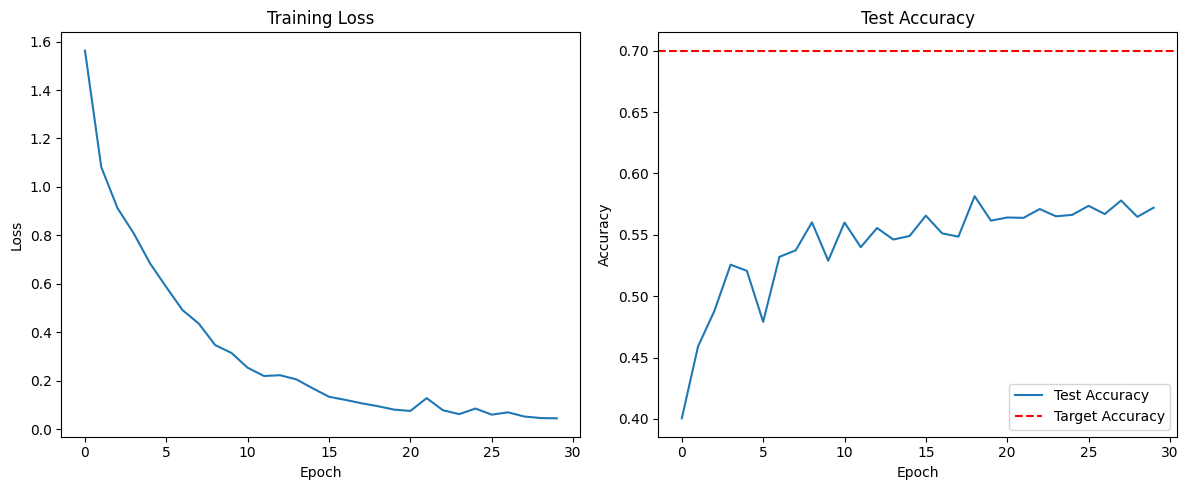

In [ ]:
# Generate plots
plot_training_history(history)

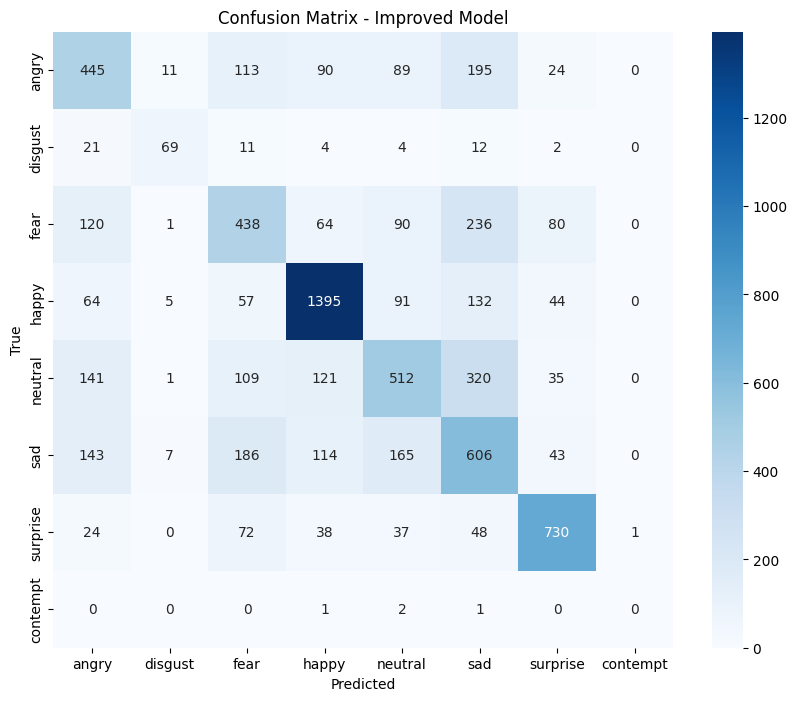

In [22]:
#Confusion Matrix
plot_confusion_matrix(labels, preds)

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Load the trained models
model2 = Model2_EmotionResNet(num_classes=8)
model2.load_state_dict(torch.load('best_emotion_resnet.pth'))
model2 = model2.to(device)
model2.eval()

model3 = ImprovedResNet18(num_classes=8)
model3.load_state_dict(torch.load('best_improved_resnet.pth'))
model3 = model3.to(device)
model3.eval()

# Emotion labels
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'contempt']

# Sample test images
test_images = [
    ('sample_data/happy.jpg', 'happy'),
    ('sample_data/angry.jpg', 'angry'),
    ('sample_data/surprised.jpg', 'surprise')
]


def load_and_preprocess_image(file_path):
    """Load image from local path and preprocess for model input"""
    image = cv2.imread(file_path)
    if image is None:
        print(f"Failed to load image: {file_path}")
        return None, None

    # Convert to RGB for display
    display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Detect face
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        print("No face detected in image")
        return None, None

    x, y, w, h = faces[0]

    # Preprocess face
    face = image[y:y+h, x:x+w]
    face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    face_resized = cv2.resize(face_gray, (48, 48))
    face_normalized = face_resized / 255.0
    face_tensor = torch.from_numpy(face_normalized).float().unsqueeze(0).unsqueeze(0).to(device)

    # Create annotated image
    annotated_image = cv2.rectangle(image.copy(), (x, y), (x+w, y+h), (255, 0, 0), 2)

    return face_tensor, cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

def test_models_on_images():
    for img_url, true_label in test_images:
        print(f"\nTesting image with true label: {true_label}")
        print("="*50)

        # Load and preprocess image
        face_tensor, display_image = load_and_preprocess_image(img_url)
        if face_tensor is None:
            continue

        # Get predictions
        with torch.no_grad():
            output2 = model2(face_tensor)
            output3 = model3(face_tensor)

            prob2 = torch.nn.functional.softmax(output2, dim=1)
            prob3 = torch.nn.functional.softmax(output3, dim=1)

            conf2, pred2 = torch.max(prob2, 1)
            conf3, pred3 = torch.max(prob3, 1)

            emotion2 = emotion_labels[pred2.item()]
            emotion3 = emotion_labels[pred3.item()]

        plt.figure(figsize=(10, 5))
        plt.imshow(display_image)
        plt.title(f"Original Label: {true_label}\n"
                 f"ResNet18 Prediction: {emotion2} ({conf2.item():.2f})\n"
                 f"Improved Model Prediction: {emotion3} ({conf3.item():.2f})")
        plt.axis('off')
        plt.show()

        # Print detailed
        print(f"ResNet18 Prediction: {emotion2} (Confidence: {conf2.item():.2f})")
        print(f"Improved Model Prediction: {emotion3} (Confidence: {conf3.item():.2f})")
        print("\nModel 2 Probabilities:")
        for i, prob in enumerate(prob2[0]):
            print(f"{emotion_labels[i]}: {prob.item():.4f}")
        print("\nModel 3 Probabilities:")
        for i, prob in enumerate(prob3[0]):
            print(f"{emotion_labels[i]}: {prob.item():.4f}")

test_models_on_images()



Testing image with true label: happy
No face detected in image

Testing image with true label: angry
No face detected in image

Testing image with true label: surprise
Failed to load image: sample_data/surprised.jpg
